In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator
import os

In [3]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [5]:
import sys
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks")
from plot_utils import plot_histogram

In [17]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/inelasticity/inelasticity_globalfit"
os.system(f"mkdir -p {plotting_path}")

0

In [7]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"

Let's first check hese

In [18]:
config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/Poisson/hese/hese_HESEBestfit_SPL.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_hese.cfg",
                               "override/datasets_hese/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10_fluxlessweight.cfg",
                               "override/binning/hese/10bdtprod_threshold_0.122.cfg"],
        override_components_files=["override/components/astro_SPL.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()

IC86_pass2_SnowStorm_FTP_HESE_Cascades


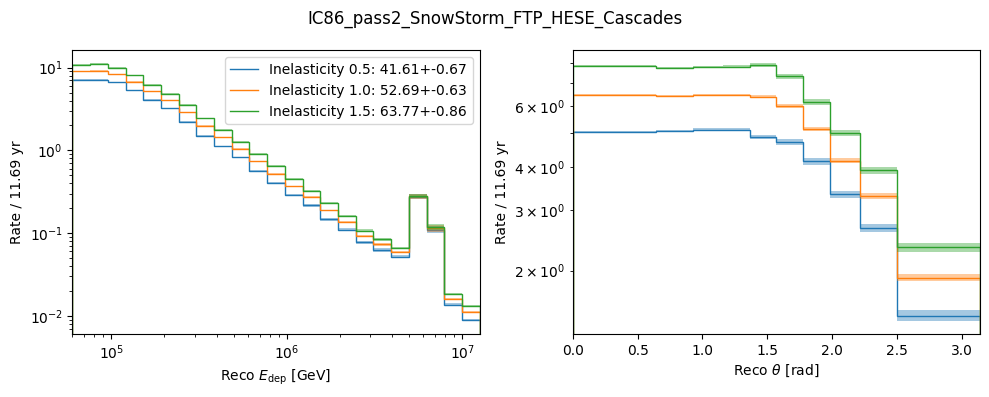

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


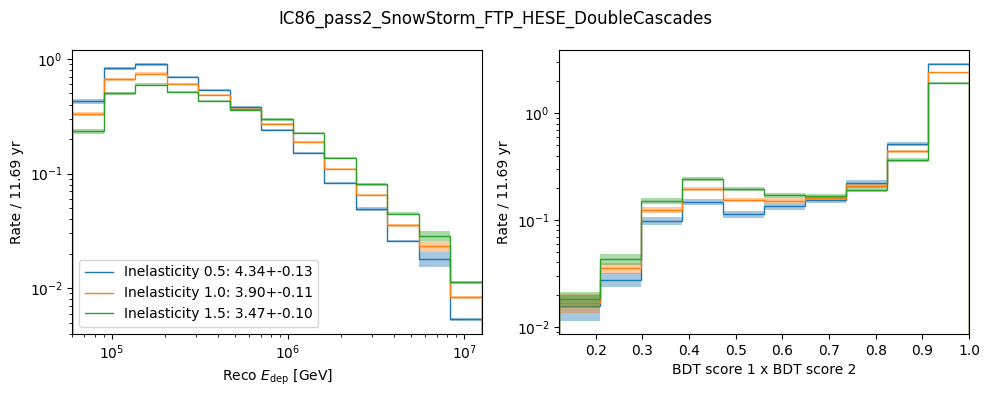

IC86_pass2_SnowStorm_FTP_HESE_Tracks


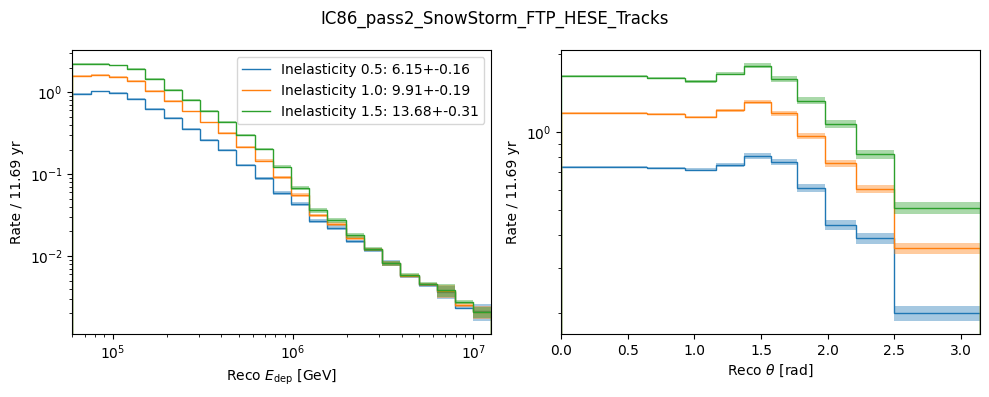

In [19]:
plotting_path_histogram = f"{plotting_path}/hese"
os.system(f"mkdir -p {plotting_path_histogram}")

input_variables = {
    r"Inelasticity 0.5" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "inel_scale" : 0.5},
    r"Inelasticity 1.0" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "inel_scale" : 1.0},
    r"Inelasticity 1.5" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "inel_scale" : 1.5},
}
for det_config in detector_configs: 
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=True, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-True.png")


Now let's try the globalfit

In [20]:
config_hdl = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/Poisson/globalfit/globalfit_double_no_hybrid_SPL.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_GP_globalfit.cfg",
                               "override/datasets_GP_globalfit/v2/globalfit_no_overlap_v2.cfg"],
        override_components_files=["override/components/astro_SPL.yaml"],
        override_parameters_files=None)
hist_graph_hdl = HistogramGraph(config_hdl)
detector_configs = config_hdl.get_det_configs()

IC86_pass2_SnowStorm_v2_tracks


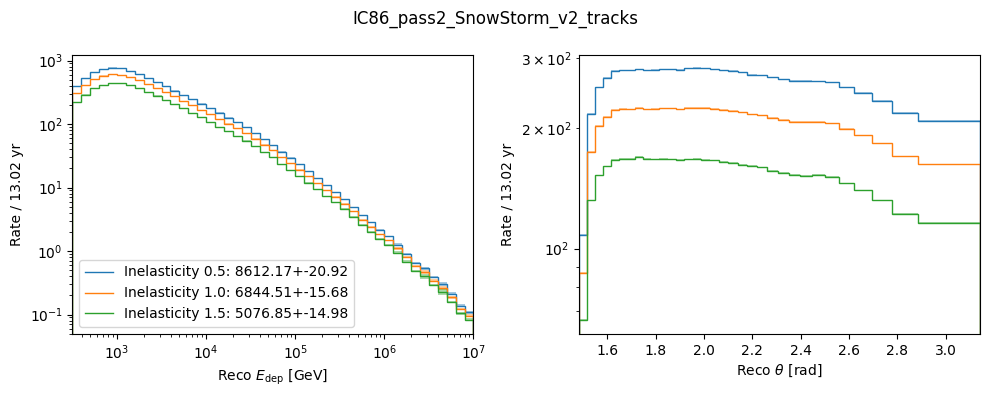

IC86_pass2_SnowStorm_v2_cscd_muon


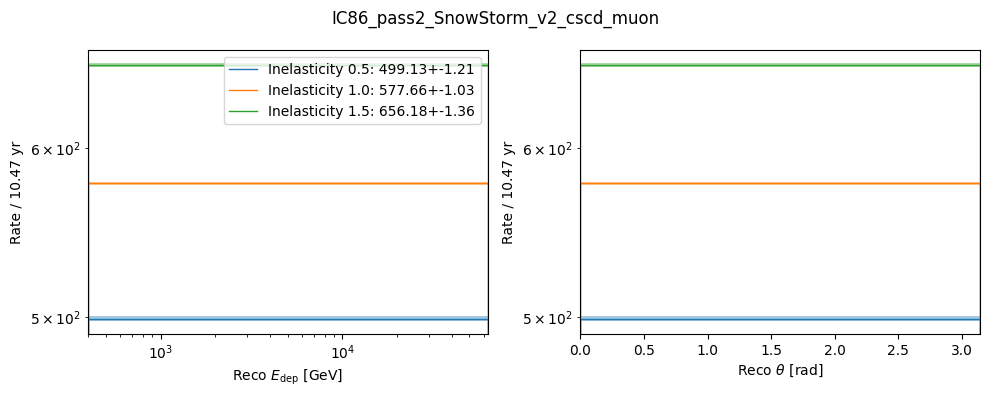

IC86_pass2_SnowStorm_v2_cscd_cascade


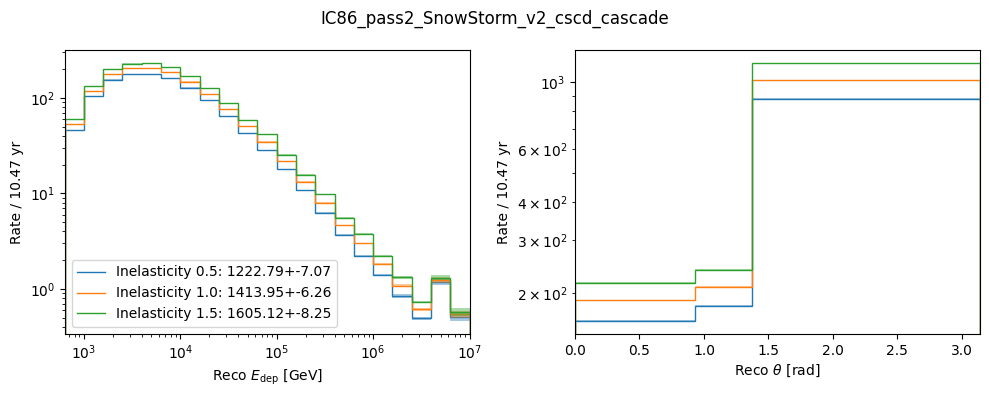

IC86_pass2_SnowStorm_v2_cscd_cascade_double


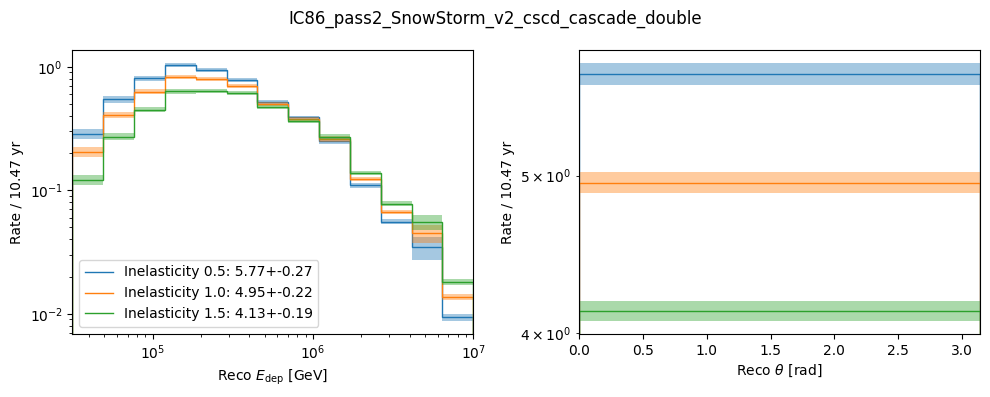

In [21]:
plotting_path_histogram = f"{plotting_path}/globalfit"
os.system(f"mkdir -p {plotting_path_histogram}")

input_variables = {
    r"Inelasticity 0.5" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0, "inel_scale" : 0.5},
    r"Inelasticity 1.0" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0, "inel_scale" : 1.0},
    r"Inelasticity 1.5" : {"astro_norm" : 1.8, "prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0, "muon_norm" : 0, "inel_scale" : 1.5},
}
for det_config in detector_configs: 
    plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=True, 
                   savepath=f"{plotting_path_histogram}/{det_config}_ylog-True.png")
